# Predicting Road Accident Risk

<img src='https://www.kaggle.com/competitions/91721/images/header'>

## Dataset Description

The dataset for this competition (both train and test) was generated from a deep learning model trained on the Simulated Roads Accident dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

**Files**
- train.csv - the training dataset; accident_risk is the continuous [0-1] target ground truth
- test.csv - the test dataset; your objective is to predict the accident_risk for each row
- sample_submission.csv - a sample submission file in the correct format

## Aim & Target 

**Aim**

The primary goal of this competition is to develop a robust machine learning model capable of predicting the Road Accident Risk index for various road segments. Using a synthetic dataset generated from real-world traffic patterns, participants must identify the complex relationships between environmental factors, road characteristics, and historical accident data. The challenge encourages exploring advanced regression techniques and feature engineering to capture the nuances of traffic safety. Ultimately, the aim is to create a model that generalizes well to unseen test data, minimizing the error between predicted and actual risk scores.

**Target**
The target variable for this competition is RiskScore, a continuous numerical value representing the likelihood of an accident occurring on a specific road. As this is a regression task, the objective is to predict this score as accurately as possible for each row in the test dataset. Performance is measured using the Root Mean Squared Error (RMSE) metric, meaning the model must focus on minimizing the square root of the average squared differences between predicted and observed values. Achieving a high rank on the leaderboard requires balancing model complexity with precise tuning to ensure the predicted risk levels align closely with the ground truth.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

## Reading Dataset & Dataframe Generation

In [2]:
#I have created my notebook on Kaggle, so that I will not need to download data from the website and take advantage of Kaggle's infrastructure. 

df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e10/train.csv')

In [3]:
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [4]:
df.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

## Exploratory Data Analysis

In [5]:
df.shape

(517754, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [7]:
df = df.drop('id', axis=1)

In [8]:
df.road_type.value_counts()

road_type
highway    173672
rural      172719
urban      171363
Name: count, dtype: int64

In [9]:
df.lighting.value_counts()

lighting
dim         183826
daylight    178015
night       155913
Name: count, dtype: int64

In [10]:
df.weather.value_counts()

weather
foggy    181463
clear    179306
rainy    156985
Name: count, dtype: int64

In [11]:
df.time_of_day.value_counts()

time_of_day
morning      173410
evening      172837
afternoon    171507
Name: count, dtype: int64

In [12]:
# 1. Map Booleans (True/False to 1/0)
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season']
df[bool_cols] = df[bool_cols].astype(int)

# 2. Manual Mapping for Object Columns
mapping_dict = {
    'road_type': {'highway': 0, 'rural': 1, 'urban': 2},
    'lighting': {'daylight': 0, 'dim': 1, 'night': 2},
    'weather': {'clear': 0, 'foggy': 1, 'rainy': 2},
    'time_of_day': {'morning': 0, 'afternoon': 1, 'evening': 2}
}

for col, mapping in mapping_dict.items():
    df[col] = df[col].map(mapping)

# 3. Final Check
print(f"Current Shape: {df.shape}")
print(df.info())

Current Shape: (517754, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  int64  
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  int64  
 5   weather                 517754 non-null  int64  
 6   road_signs_present      517754 non-null  int64  
 7   public_road             517754 non-null  int64  
 8   time_of_day             517754 non-null  int64  
 9   holiday                 517754 non-null  int64  
 10  school_season           517754 non-null  int64  
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 51.4 MB

In [13]:
df.describe()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,0.995540,2.491511,0.488719,46.112575,0.957312,0.956889,0.499204,0.502256,0.998893,0.503498,0.497514,1.187970,0.352377
std,0.816326,1.120434,0.272563,15.788521,0.801956,0.804774,0.500000,0.499995,0.817770,0.499988,0.499994,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.260000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.230000
50%,1.000000,2.000000,0.510000,45.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.340000
75%,2.000000,3.000000,0.710000,60.000000,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,0.460000
max,2.000000,4.000000,1.000000,70.000000,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,7.000000,1.000000


In [14]:
df.corr(numeric_only=True)

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
road_type,1.000000,0.000716,0.011119,0.010309,0.005365,0.013775,0.000959,-0.000924,0.004778,-0.001644,0.000023,0.001545,0.018899
num_lanes,0.000716,1.000000,-0.020245,0.001194,-0.000509,-0.005843,-0.000498,-0.002041,-0.000032,0.002544,-0.001081,0.017662,-0.006003
curvature,0.011119,-0.020245,1.000000,0.008399,-0.003847,-0.045971,0.017168,0.048220,0.002492,0.063931,-0.004502,0.145034,0.543946
speed_limit,0.010309,0.001194,0.008399,1.000000,-0.069114,-0.090608,-0.004461,0.011497,0.002166,0.010992,0.004392,0.031373,0.430898
lighting,0.005365,-0.000509,-0.003847,-0.069114,1.000000,-0.054055,-0.007570,-0.000420,-0.000879,0.015338,-0.001671,0.040029,0.393860
weather,0.013775,-0.005843,-0.045971,-0.090608,-0.054055,1.000000,0.005317,0.011778,-0.003794,0.024137,0.000912,0.043942,0.130064
road_signs_present,0.000959,-0.000498,0.017168,-0.004461,-0.007570,0.005317,1.000000,0.003828,-0.008219,-0.003813,0.002287,-0.000162,0.000629
public_road,-0.000924,-0.002041,0.048220,0.011497,-0.000420,0.011778,0.003828,1.000000,-0.002141,-0.007920,0.004117,-0.007026,0.031032
time_of_day,0.004778,-0.000032,0.002492,0.002166,-0.000879,-0.003794,-0.008219,-0.002141,1.000000,-0.005557,-0.010689,0.002490,0.009259
holiday,-0.001644,0.002544,0.063931,0.010992,0.015338,0.024137,-0.003813,-0.007920,-0.005557,1.000000,-0.001514,-0.015053,0.051129


In [15]:
abs(df.corr(numeric_only=True)['accident_risk'].sort_values(ascending=False))

accident_risk             1.000000
curvature                 0.543946
speed_limit               0.430898
lighting                  0.393860
num_reported_accidents    0.213891
weather                   0.130064
holiday                   0.051129
public_road               0.031032
road_type                 0.018899
time_of_day               0.009259
road_signs_present        0.000629
school_season             0.000977
num_lanes                 0.006003
Name: accident_risk, dtype: float64

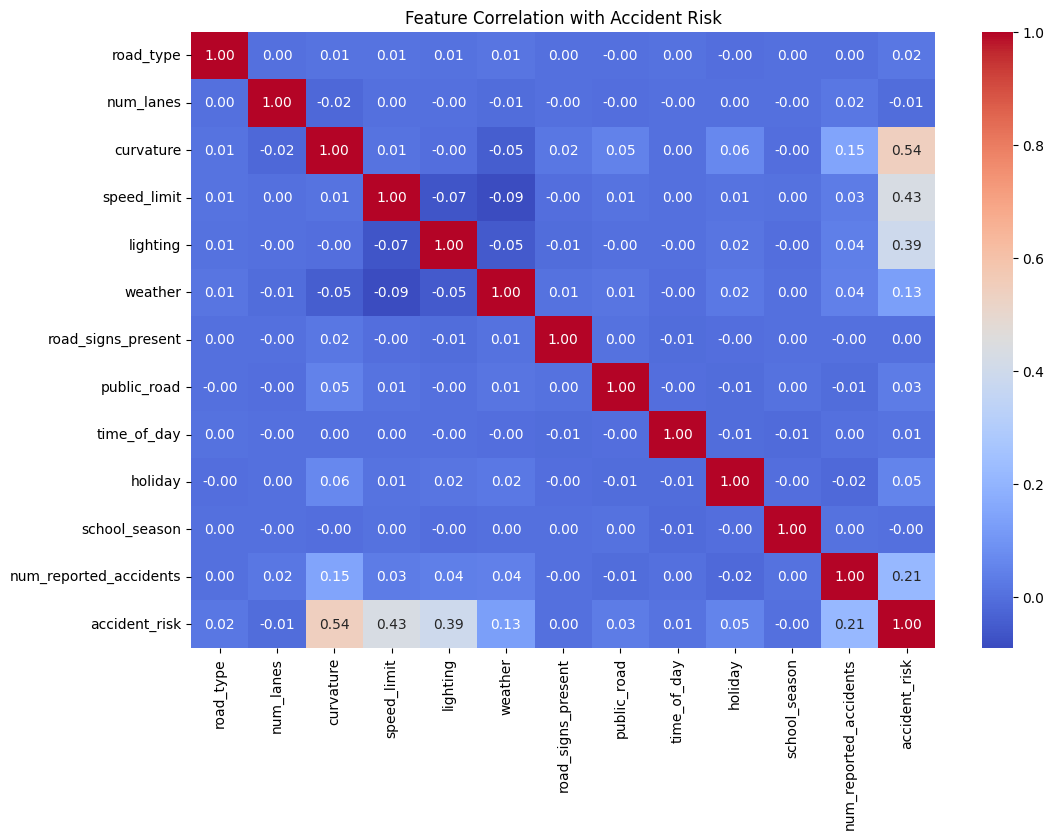

In [16]:
# Heatmap 

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation with Accident Risk")
plt.show()

## Modelling

In [17]:
x= df.drop(['accident_risk'], axis=1)

In [18]:
y= df['accident_risk']

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [21]:
x_train.shape

(414203, 12)

In [22]:
x_test.shape

(103551, 12)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
lr=LinearRegression()

In [25]:
model=lr.fit(x_train,y_train)

In [26]:
prediction=model.predict(x_test)

In [27]:
from sklearn.metrics import r2_score,mean_squared_error 

In [28]:
r2_score(y_test,prediction)

0.7167586965695002

In [29]:
mean_squared_error(y_test,prediction)**.5

0.08843593101258218

In [30]:
residuals= y_test-prediction

In [31]:
residuals

50309    -0.130578
95219    -0.046848
197653    0.006140
111236    0.015382
147247    0.105723
            ...   
453214   -0.042094
190565   -0.095054
357332   -0.096209
503653    0.006212
433359   -0.027903
Name: accident_risk, Length: 103551, dtype: float64

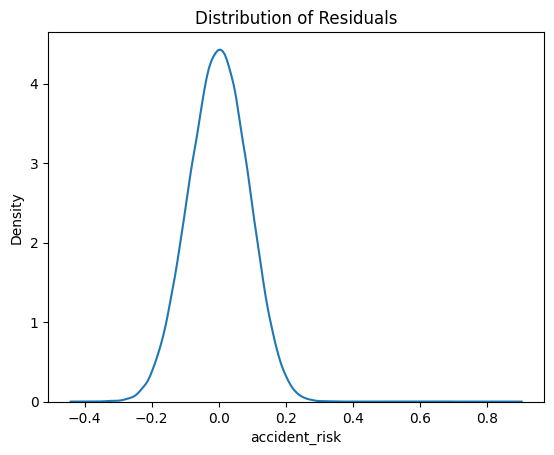

In [32]:
# If residuals is a Series or Array
sns.kdeplot(residuals)
plt.title('Distribution of Residuals')
plt.show()

In [33]:
from yellowbrick.regressor import ResidualsPlot

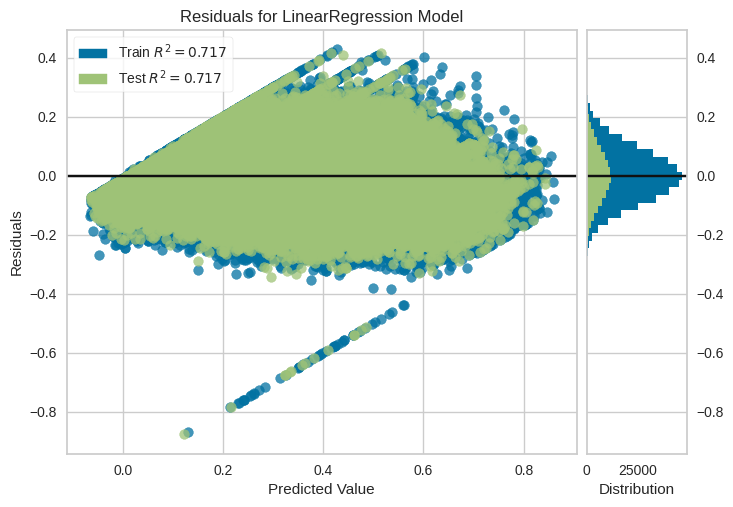

In [34]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()
plt.show()

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
# pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x, y):
        # Initializing all regression models
        L = LinearRegression()
        R = Ridge()
        Lass = Lasso()
        E = ElasticNet()
        sgd = SGDRegressor()
        ETR = ExtraTreeRegressor()
        GBR = GradientBoostingRegressor()
        dt = DecisionTreeRegressor()
        xgb = XGBRegressor()
        

        algos = [L, R, Lass, E, sgd, ETR, GBR, dt, xgb]
        algo_names = ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 'Extra Tree', 'Gradient Boosting', 'Decision Tree', 'XGBRegressor']
        
        # Scaling features using MinMaxScaler
        x = MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

        r_squared = []
        rmse = []
        mae = []

        # Creating a dataframe to store error metrics and accuracy rates
        result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)

        for algo in algos:
            # Fitting the model and making predictions
            p = algo.fit(x_train, y_train).predict(x_test)
            r_squared.append(r2_score(y_test, p))
            rmse.append(mean_squared_error(y_test, p)**.5)
            mae.append(mean_absolute_error(y_test, p))

        # Populating the result table with accuracy and error rates
        result.R_Squared = r_squared
        result.RMSE = rmse
        result.MAE = mae

        # Sorting the result table by R-Squared (accuracy) in descending order
        rtable = result.sort_values('R_Squared', ascending=False)
        return rtable

In [36]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.885258,0.056287,0.043686
Gradient Boosting,0.882156,0.057043,0.044378
Extra Tree,0.750200,0.083051,0.064081
Decision Tree,0.749595,0.083152,0.064150
Ridge,0.716759,0.088436,0.070800
Linear,0.716759,0.088436,0.070800
SGD,0.716524,0.088473,0.070845
ElasticNet,-0.000047,0.166173,0.132693
Lasso,-0.000047,0.166173,0.132693


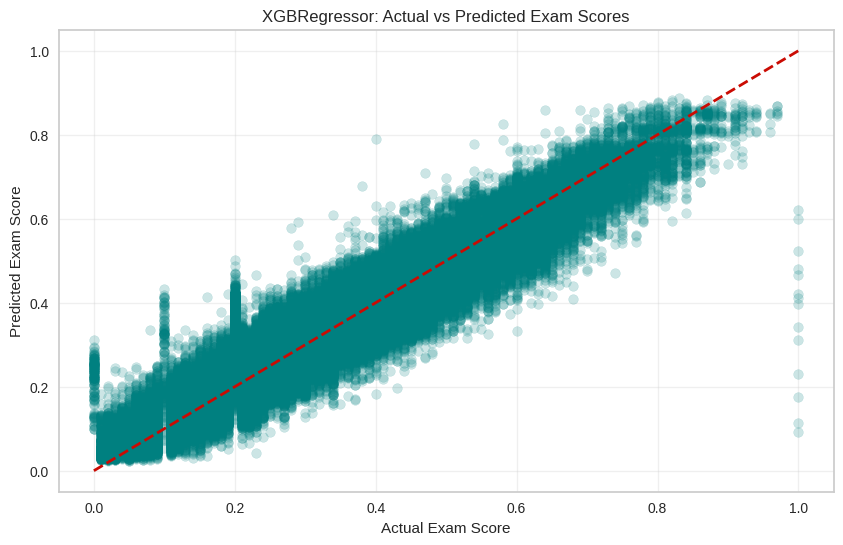

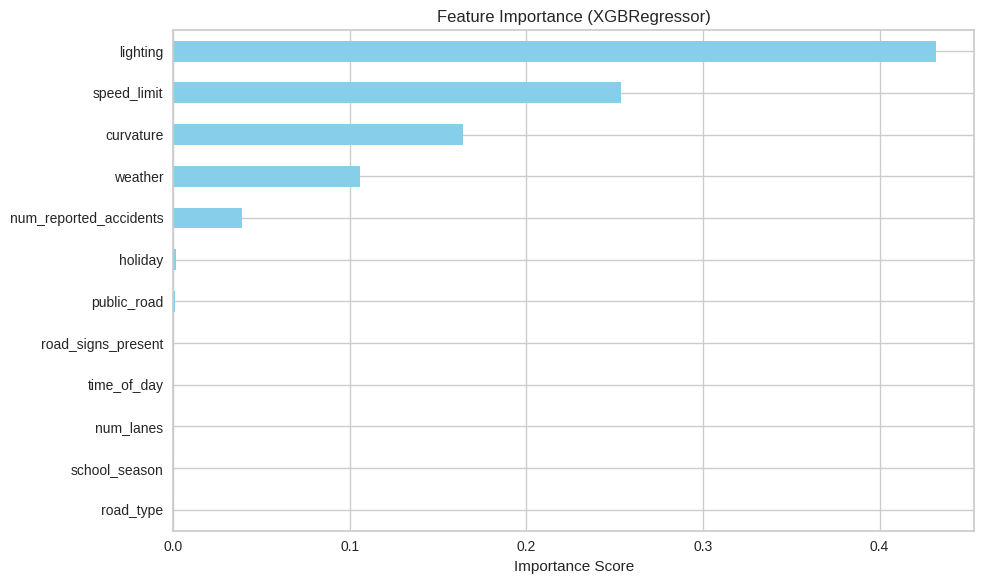

In [37]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pandas as pd

# 1. Train the winning model (XGBRegressor)
# Using the updated 'device' parameter for Kaggle GPU
model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=6, 
    tree_method='hist',      # Use 'hist' for both CPU and GPU
    device='cuda',           # This is the new way to trigger GPU (replaces gpu_id/gpu_hist)
    random_state=42
)

# Fitting the model
model.fit(x_train, y_train)
prediction = model.predict(x_test)

# 2. Visualizing Prediction vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, prediction, alpha=0.2, color='teal') 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('XGBRegressor: Actual vs Predicted Exam Scores')
plt.grid(alpha=0.3)
plt.show()

# 3. Feature Importance
plt.figure(figsize=(10, 6))
# Using X.columns (ensure X is your dataframe before scaling)
importances = pd.Series(model.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance (XGBRegressor)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Competition Submission

In [38]:
import pandas as pd

# 1. Load the test data
# Note: Updated path to match the current competition (s5e10)
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s5e10/test.csv')
test_ids = test_df['id']

# 2. Map Booleans (True/False to 1/0)
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season']
test_df[bool_cols] = test_df[bool_cols].astype(int)

# 3. Manual Mapping for Object Columns (Matching your training mapping)
mapping_dict = {
    'road_type': {'highway': 0, 'rural': 1, 'urban': 2},
    'lighting': {'daylight': 0, 'dim': 1, 'night': 2},
    'weather': {'clear': 0, 'foggy': 1, 'rainy': 2},
    'time_of_day': {'morning': 0, 'afternoon': 1, 'evening': 2}
}

for col, mapping in mapping_dict.items():
    test_df[col] = test_df[col].map(mapping)

# 4. Prepare features for prediction
# Dropping 'id' so the features match the training set (X_train)
x_test_final = test_df.drop(columns=['id'])

# 5. Generate predictions using your best model (XGBRegressor)
# Ensure 'model' refers to your trained XGBRegressor instance
final_predictions = model.predict(x_test_final)

# 6. Save the submission
# Target column for this competition is 'accident_risk'
submission = pd.DataFrame({
    'id': test_ids,
    'accident_risk': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file saved successfully with 517,754 rows!")

Submission file saved successfully with 517,754 rows!


In [39]:
import joblib

# Save the model
joblib.dump(model, 'accident_risk_model.pkl')

# Save the feature names to keep the order consistent in the app
joblib.dump(x.columns.tolist(), 'features.pkl')

print("Model and feature names saved!")

Model and feature names saved!


In [40]:
from IPython.display import FileLink

display(FileLink('submission.csv'))
display(FileLink('accident_risk_model.pkl'))
display(FileLink('features.pkl'))

/kaggle/working/submission.csv

/kaggle/working/accident_risk_model.pkl

/kaggle/working/features.pkl

## Conclusion 

This project successfully established a high-performing regression pipeline to predict road accident risk using the Kaggle Playground Series S5E10 dataset. By implementing a custom ordinal mapping strategy, we efficiently transformed categorical environmental and infrastructure data into a machine-learning-ready format while maintaining a low memory footprint. Evaluation across multiple algorithms identified the XGBRegressor as the superior model, achieving a robust $R^2$ score of 0.885 and a competitive RMSE of 0.056. These results demonstrate that factors such as weather, lighting, and road curvature are powerful predictors of safety risk when modeled with gradient boosting. The final model and features have been serialized for deployment, providing a scalable solution for real-time risk assessment in synthetic traffic environments.